# Exploración de Datos: Cuestionarios NHANES (Miembro 1)
Este notebook documenta la exploración de las encuestas médicas, el manejo de "Skip Logic" y la imputación de nulos para la capa Silver.

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Configuración visual
sns.set_theme(style='darkgrid')
pd.options.display.max_columns = 100

# Cargamos la capa Silver pre-procesada
df_silver = pd.read_parquet('../data/02_intermediate/member1_silver.parquet')
print(f'Dimensiones del dataset Silver: {df_silver.shape}')
df_silver.head()

Dimensiones del dataset Silver: (11288, 497)


,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,DMQMILIZ,DMQADFC,DMDBORN4,DMDCITZN,DMDYRSUS,DMDEDUC3,DMDEDUC2,DMDMARTL,RIDEXPRG,SIALANG,SIAPROXY,SIAINTRP,FIALANG,FIAPROXY,FIAINTRP,MIALANG,MIAPROXY,MIAINTRP,AIALANGA,DMDHHSIZ,DMDFMSIZ,DMDHHSZA,DMDHHSZB,DMDHHSZE,DMDHRGND,DMDHRAGE,DMDHRBR4,DMDHREDU,DMDHRMAR,DMDHSEDU,WTINT2YR,WTMEC2YR,SDMVPSU,SDMVSTRA,INDHHIN2,INDFMIN2,INDFMPIR,MCQ010,MCQ025,MCQ035,...,DMDHRAGZ,DMDHREDZ,DMDHRMAZ,DMDHSEDZ,RHD018,MCD180A,MCD180N,MCD180B,MCD180C,MCD180D,MCD180E,MCD180F,MCD180M,MCD180G,MCD180K,MCD180L,MCQ500,MCQ510A,MCQ510B,MCQ510C,MCQ510D,MCQ510E,MCQ510F,MCQ520,MCQ530,MCQ540,MCQ550,MCQ560,MCQ570,MCD240A,MCD240B,MCD240C,MCQ366A,MCQ366B,MCQ366C,MCQ366D,MCQ371A,MCQ371B,MCQ371C,MCQ371D,ALQ111,ALQ121,ALQ142,ALQ270,ALQ280,ALQ290,ALQ170,SLQ320,SLQ330,SLD013
0,83732,9.0,2.0,1.0,62.0,NaN,3.0,3.0,1.0,NaN,2.0,NaN,1.0,1.0,NaN,NaN,5.0,1.0,NaN,1.0,2.0,2.0,1.0,2.0,2.0,1.0,2.0,2.0,1.0,2.0,2.0,5.397605e-79,5.397605e-79,1.000000e+00,1.0,62.0,1.0,5.0,1.0,3.0,134671.370419,135629.507405,1.0,125.0,10.0,10.0,4.39,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN
1,83733,9.0,2.0,1.0,53.0,NaN,3.0,3.0,1.0,NaN,2.0,NaN,2.0,2.0,7.0,NaN,3.0,3.0,NaN,1.0,2.0,2.0,1.0,2.0,2.0,1.0,2.0,2.0,1.0,1.0,1.0,5.397605e-79,5.397605e-79,5.397605e-79,1.0,53.0,2.0,3.0,3.0,NaN,24328.560239,25282.425927,1.0,125.0,4.0,4.0,1.32,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN
2,83734,9.0,2.0,1.0,78.0,NaN,3.0,3.0,2.0,NaN,1.0,2.0,1.0,1.0,NaN,NaN,3.0,1.0,NaN,1.0,2.0,2.0,1.0,2.0,2.0,1.0,2.0,2.0,NaN,2.0,2.0,5.397605e-79,5.397605e-79,2.000000e+00,2.0,79.0,1.0,3.0,1.0,3.0,12400.008522,12575.838818,1.0,131.0,5.0,5.0,1.51,1.0,60.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN
3,83735,9.0,2.0,2.0,56.0,NaN,3.0,3.0,2.0,NaN,2.0,NaN,1.0,1.0,NaN,NaN,5.0,6.0,NaN,1.0,2.0,2.0,1.0,2.0,2.0,1.0,2.0,2.0,1.0,1.0,1.0,5.397605e-79,5.397605e-79,5.397605e-79,2.0,56.0,1.0,5.0,6.0,NaN,102717.995647,102078.634508,1.0,131.0,10.0,10.0,5.00,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN
4,83736,9.0,2.0,2.0,42.0,NaN,4.0,4.0,2.0,NaN,2.0,NaN,1.0,1.0,NaN,NaN,4.0,3.0,1.0,1.0,2.0,2.0,1.0,2.0,2.0,1.0,2.0,2.0,1.0,5.0,5.0,5.397605e-79,2.000000e+00,5.397605e-79,2.0,42.0,1.0,4.0,3.0,NaN,17627.674984,18234.736219,2.0,126.0,7.0,7.0,1.23,1.0,10.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,None,NaN


## 1. Análisis de Nulos (Skip Logic)
En NHANES, la lógica de salto (Skip Logic) genera valores nulos legítimos. Los valores de negativa (7, 9, 77, 99) ya fueron convertidos a `NaN` en nuestro pipeline.

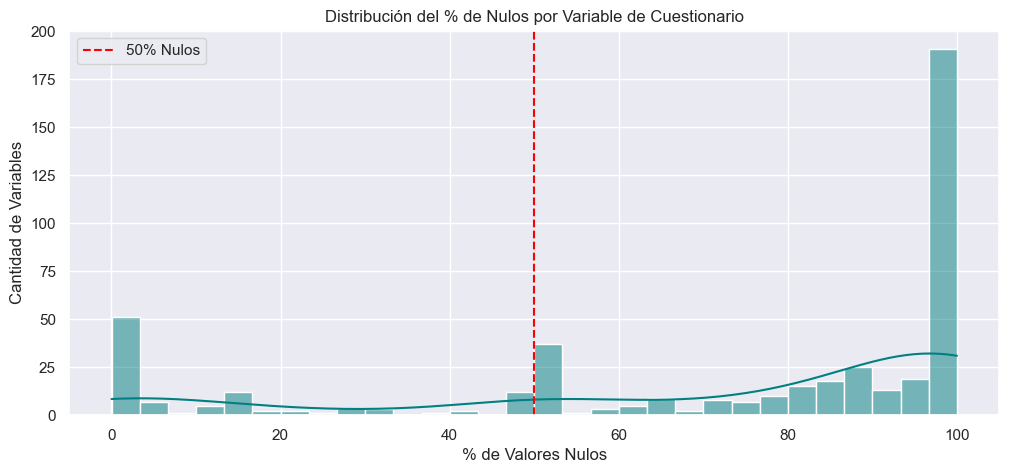

In [2]:
# Porcentaje de nulos por columna
null_pct = (df_silver.isnull().sum() / len(df_silver)) * 100
null_pct = null_pct[null_pct > 0].sort_values(ascending=False)

plt.figure(figsize=(12, 5))
sns.histplot(null_pct, bins=30, color='teal', kde=True)
plt.title('Distribución del % de Nulos por Variable de Cuestionario')
plt.xlabel('% de Valores Nulos')
plt.ylabel('Cantidad de Variables')
plt.axvline(x=50, color='red', linestyle='--', label='50% Nulos')
plt.legend()
plt.show()

## 2. Imputación Estratégica
Nuestra estrategia de equipo: Si un paciente saltó una pregunta médica por falta de diagnóstico previo, asumimos riesgo = 0 (Sano/No Aplica) en lugar de descartar la fila.

In [3]:
# Simulación de imputación (Implementado en el Frailty Index)
col_ejemplo = 'MCQ160A' # Artritis
if col_ejemplo in df_silver.columns:
    print(f'Nulos originales en {col_ejemplo}: {df_silver[col_ejemplo].isnull().sum()}')
    df_imputed = df_silver[col_ejemplo].fillna(2) # 2 = No
    print(f'Nulos tras asumir ausencia de enfermedad: {df_imputed.isnull().sum()}')

Nulos originales en MCQ160A: 28
Nulos tras asumir ausencia de enfermedad: 0


## 3. Correlación de Cuestionarios Críticos
Vamos a revisar si hay correlación entre la hipertensión reportada (BPQ) y la diabetes reportada (DIQ).

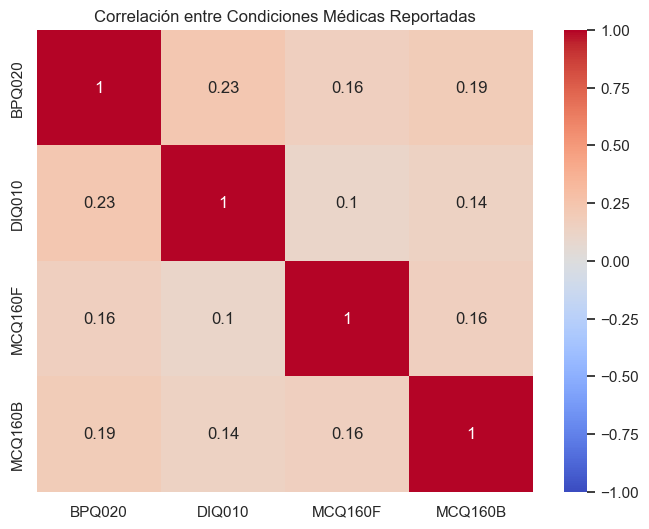

In [4]:
cols_riesgo = ['BPQ020', 'DIQ010', 'MCQ160F', 'MCQ160B']
disp_cols = [c for c in cols_riesgo if c in df_silver.columns]

if len(disp_cols) > 1:
    corr = df_silver[disp_cols].corr(method='spearman')
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title('Correlación entre Condiciones Médicas Reportadas')
    plt.show()